[*********************100%***********************]  1 of 1 completed


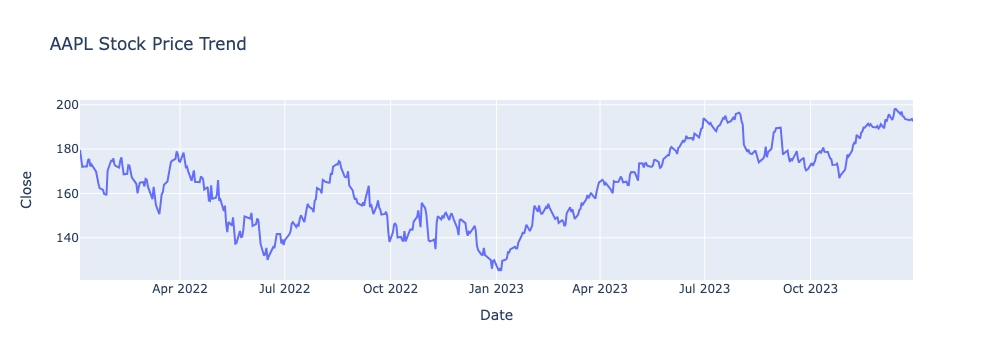

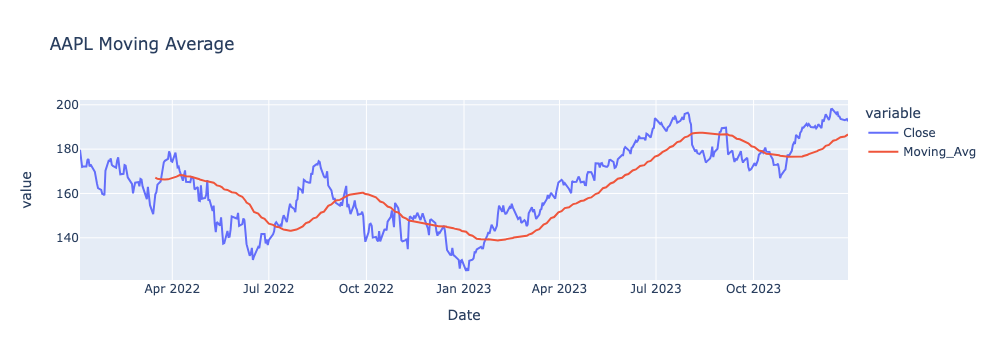

Mean Absolute Error: 12.23


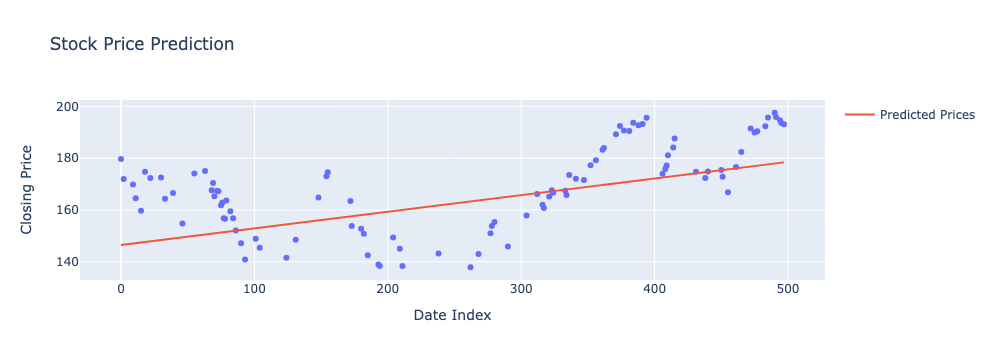

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Step 1: Download Stock Data
def get_stock_data(ticker, start, end):
    stock = yf.download(ticker, start=start, end=end)
    stock['Daily_Return'] = stock['Close'].pct_change()
    return stock.dropna()

# Step 2: Perform EDA
def plot_stock_trend(stock_data, ticker):
    fig = px.line(stock_data, x=stock_data.index, y='Close', title=f'{ticker} Stock Price Trend')
    fig.show()

# Step 3: Calculate Moving Averages
def plot_moving_average(stock_data, ticker, window=50):
    stock_data['Moving_Avg'] = stock_data['Close'].rolling(window=window).mean()
    fig = px.line(stock_data, x=stock_data.index, y=['Close', 'Moving_Avg'], title=f'{ticker} Moving Average')
    fig.show()

# Step 4: Regression Analysis & Prediction
def predict_stock_prices(stock_data):
    stock_data['Date'] = stock_data.index.factorize()[0]  # Convert dates to numerical format
    X = stock_data[['Date']]
    y = stock_data['Close']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f'Mean Absolute Error: {mae:.2f}')
    
    fig = px.scatter(x=X_test['Date'], y=y_test, labels={'x': 'Date Index', 'y': 'Closing Price'}, title='Stock Price Prediction')
    fig.add_scatter(x=X_test['Date'], y=y_pred, mode='lines', name='Predicted Prices')
    fig.show()

# Example Usage
ticker = 'AAPL'
start_date = '2022-01-01'
end_date = '2024-01-01'

data = get_stock_data(ticker, start_date, end_date)
plot_stock_trend(data, ticker)
plot_moving_average(data, ticker, window=50)
predict_stock_prices(data)
